# Q3: What predicts movepool size (versatility)?

**Question:** What makes a Pokemon learn a lot of moves -- is it raw power, type, category, or
simply how many games it's been around for?

Sub-questions:
- Does movepool size correlate with total stats -- are strong Pokemon also versatile ones?
- Does it correlate more strongly with the number of game versions a Pokemon appears in (a
  confound: older/more-reissued Pokemon accumulate moves over time regardless of strength)?
- After accounting for that confound, is there still a stats-versatility relationship?
- Do legendary/mythical/baby Pokemon have smaller movepools than normal Pokemon (a common design
  pattern -- legendaries are often move-restricted)?
- Which types have the deepest and shallowest movepools?


## 1. Setup & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
%matplotlib inline

pokemon = pd.read_csv("data/pokemon.csv")
types = pd.read_csv("data/types.csv")
moves = pd.read_csv("data/moves.csv")
versions = pd.read_csv("data/regions.csv").rename(columns={"region_id": "version_id", "region_name": "version_name"})

stat_cols = ["hp", "attack", "defense", "special-attack", "special-defense", "speed"]
pokemon["total_stats"] = pokemon[stat_cols].sum(axis=1)

def categorize(row):
    if row["is_legendary"]:
        return "legendary"
    if row["is_mythical"]:
        return "mythical"
    if row["is_baby"]:
        return "baby"
    return "normal"

pokemon["category"] = pokemon.apply(categorize, axis=1)


## 2. Build the base table: moves and versions per Pokemon

In [2]:
n_moves = moves.groupby("pokemon_id", observed=True).size().rename("n_moves")
n_versions = versions.groupby("pokemon_id", observed=True).size().rename("n_versions")

base = (
    pokemon
    .merge(n_moves, left_on="id", right_index=True, how="left")
    .merge(n_versions, left_on="id", right_index=True, how="left")
)
base["n_moves"] = base["n_moves"].fillna(0)
base["n_versions"] = base["n_versions"].fillna(0)

base[["name", "n_moves", "n_versions", "total_stats", "category"]].describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,1351,1351,bulbasaur,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_moves,1351.0,NaN,NaN,NaN,73.655811,28.581721,0.0,59.0,75.0,90.0,375.0
n_versions,1351.0,NaN,NaN,NaN,6.704663,7.583079,0.0,0.0,4.0,10.0,36.0
total_stats,1351.0,NaN,NaN,NaN,452.159141,122.456241,175.0,340.0,475.0,530.0,1125.0
category,1351,4,normal,1174,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Movepool size vs. total stats

Naive first look -- do stronger Pokemon simply know more moves?


Correlation (n_moves vs total_stats): 0.141


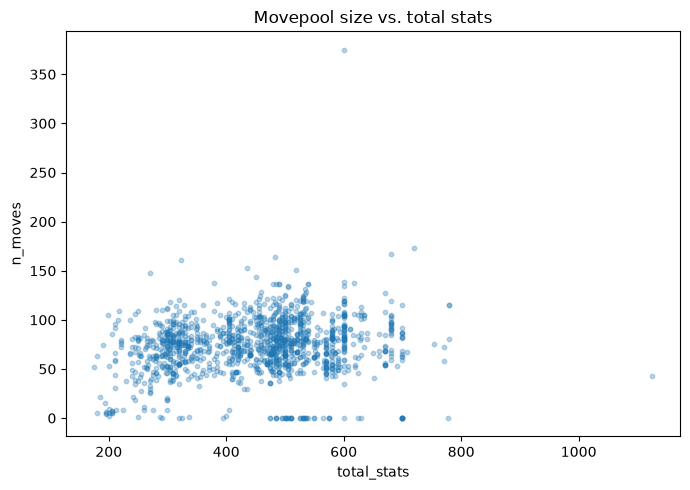

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(base["total_stats"], base["n_moves"], alpha=0.3, s=10)
ax.set_xlabel("total_stats")
ax.set_ylabel("n_moves")
ax.set_title("Movepool size vs. total stats")
plt.tight_layout()

print("Correlation (n_moves vs total_stats):", base[["n_moves", "total_stats"]].corr().iloc[0, 1].round(3))


## 4. The real driver: how many games has this Pokemon been in?

A Pokemon that's appeared in 15 game versions has had 15 games' worth of move-list updates
(TMs, tutors, egg moves) to accumulate. A Pokemon introduced in the most recent game has had one.
That's a much more direct explanation for movepool size than raw power.


Correlation (n_moves vs n_versions):     0.275
Correlation (n_versions vs total_stats): -0.384


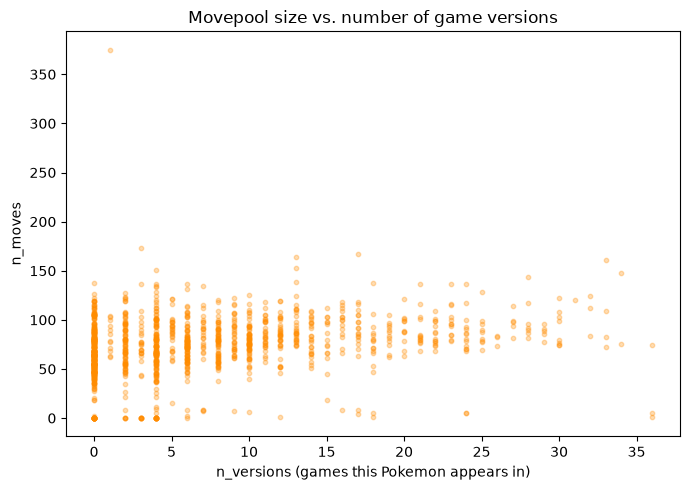

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(base["n_versions"], base["n_moves"], alpha=0.3, s=10, color="darkorange")
ax.set_xlabel("n_versions (games this Pokemon appears in)")
ax.set_ylabel("n_moves")
ax.set_title("Movepool size vs. number of game versions")
plt.tight_layout()

print("Correlation (n_moves vs n_versions):    ", base[["n_moves", "n_versions"]].corr().iloc[0, 1].round(3))
print("Correlation (n_versions vs total_stats):", base[["n_versions", "total_stats"]].corr().iloc[0, 1].round(3))


## 5. Stats vs. movepool, controlling for n_versions

Regress out the "years in the franchise" effect first (fit `n_moves ~ n_versions`, keep the
residual), then check whether stats explain what's left over.


In [5]:
fit = np.polyfit(base["n_versions"], base["n_moves"], 1)
predicted = np.poly1d(fit)(base["n_versions"])
base["n_moves_residual"] = base["n_moves"] - predicted

residual_corr = base[["n_moves_residual", "total_stats"]].corr().iloc[0, 1]
print(f"Correlation (n_moves residual vs total_stats), after removing the n_versions effect: {residual_corr:.3f}")
print(f"(raw, unadjusted correlation was {base[['n_moves','total_stats']].corr().iloc[0,1]:.3f})")


Correlation (n_moves residual vs total_stats), after removing the n_versions effect: 0.257
(raw, unadjusted correlation was 0.141)


## 6. Movepool size by category

In [6]:
base.groupby("category", observed=True)["n_moves"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)


,count,mean,median
category,,,
mythical,38,85.026316,83.0
baby,19,78.578947,85.0
normal,1174,73.333049,74.0
legendary,120,72.433333,72.0


## 7. Movepool size by type

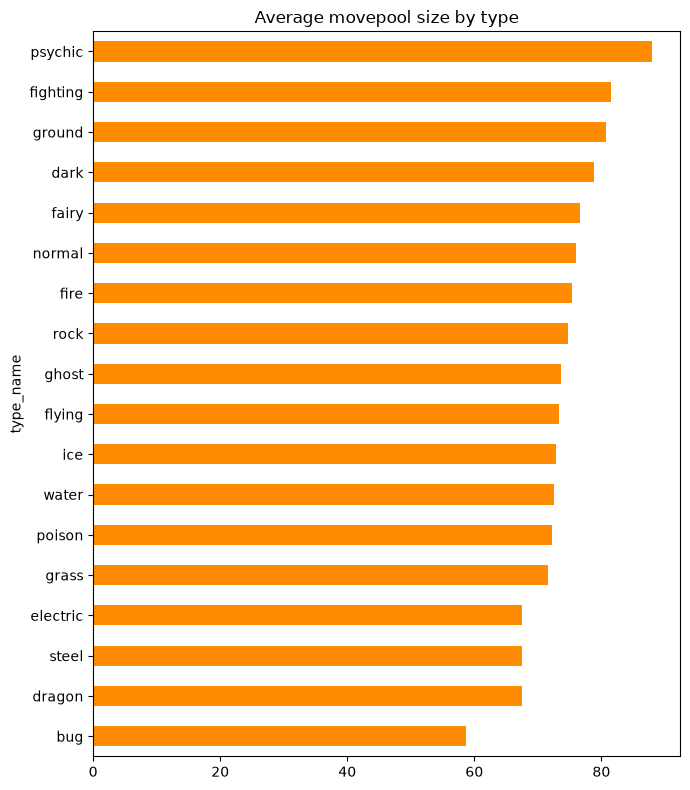

In [7]:
type_movepool = (
    types.merge(base[["id", "n_moves"]], left_on="pokemon_id", right_on="id")
    .groupby("type_name", observed=True)["n_moves"]
    .mean()
    .sort_values(ascending=False)
)
type_movepool.plot(kind="barh", figsize=(7, 8), color="darkorange")
plt.gca().invert_yaxis()
plt.title("Average movepool size by type")
plt.tight_layout()


## 8. Takeaways

*(Numbers verified independently from the raw CSV.)*

- **Raw stats barely predict movepool size.** Correlation between `total_stats` and `n_moves` is
  a weak **+0.14**. Strong Pokemon are not meaningfully more versatile than weak ones on this
  measure alone.
- **The real driver is longevity, not power -- and it points the *opposite* direction from what
  you'd naively guess.** `n_versions` (how many games a Pokemon appears in) correlates with
  `n_moves` at **+0.27** -- weak-to-moderate, but notably the *strongest* single predictor
  checked here. And `n_versions` correlates **-0.38** with `total_stats`: newer Pokemon tend to
  have both fewer game appearances *and* higher stats (consistent with power creep across
  generations -- see Q5), which is exactly the kind of confound that can flip a naive reading.
- **After controlling for n_versions, the stats relationship strengthens, it doesn't vanish.**
  Regressing out the version-count effect and correlating the residual against `total_stats`
  gives **+0.26** (vs. the raw +0.14) -- so once you're comparing Pokemon with similar franchise
  tenure, stronger Pokemon really do tend to know more moves. The naive correlation was muted
  because `n_versions` was pulling in the opposite direction.
- **Category matters less than expected.** Average movepool sizes are close across the board --
  mythical (85.0), baby (78.6), normal (73.3), legendary (72.4) -- legendaries are only modestly
  more move-restricted than ordinary Pokemon, not dramatically so.
- **Type matters more than category.** Psychic (88.0 moves avg) and fighting (81.5) have the
  deepest movepools; bug (58.7) has by far the shallowest -- a ~29-move gap, bigger than any
  category-based difference.
